# Advanced Machine Learning - Project 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, auc, roc_curve, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

In [2]:
from src.data_generation import DataGenerator
from src.fista import FistaLogisticRegression

## FISTA Algorithm (Fast Iterative Shrinkage-Thresholding Algorithm)

The FISTA (Fast Iterative Shrinkage-Thresholding Algorithm) algorithm is used to optimize problems that can be split into two parts: a smooth (differentiable) part and a non-smooth (non-differentiable but convex) part.

### Problem Formulation

$$\min_{\mathbf{w}, b} F(\mathbf{w}, b) = f(\mathbf{w}, b) + g(\mathbf{w})$$

**Smooth part** $f(\mathbf{w}, b)$ (logistic loss for binary classification $y_i \in \{-1, 1\}$):
$$f(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^n \log(1+e^{-y_i(\mathbf{w}^T\mathbf{x}_i+b)})$$

**Non-smooth part** $g(\mathbf{w})$ (L1 penalty):
$$g(\mathbf{w}) = \lambda\|\mathbf{w}\|_1$$

### FISTA Steps
The paper by Beck & Teboulle (2009) outlines "FISTA with constant stepsize" using the following steps:
- Input: $L = L(f)$ — A Lipschitz constant of $\nabla f$.
- Step 0: Take $y_1 = x_0 \in \mathbb{R}^n$, $t_1 = 1$.
- Step $k$ ($k \ge 1$): Compute:
    1. $x_k = p_L(y_k)$ 
    2. $t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$ 
    3. $y_{k+1} = x_k + \left(\frac{t_k - 1}{t_{k+1}}\right)(x_k - x_{k-1})$ 


In the paper, the Proximal Operator ($p_L$) is the core building block of both ISTA and FISTA. It is introduced in Section 2.3 ("The basic approximation model"). With some algebraic manipulation, the authors show that the proximal step can be simplified to a shrinkage (soft-thresholding) operation when the non-smooth part is the L1 norm:

$$p_L(y) = \mathcal{T}_{\lambda/L} \left( y - \frac{1}{L} \nabla f(y) \right)$$

where 

$$\mathcal{T}_{\alpha}(z) = \text{sign}(z) \cdot \max(|z| - \alpha, 0)$$
 is the shrinkage operator.

### Algorithm implementation 

**Initialization:** `x_prev = 0`, `b_prev = 0`, `y_k = x_prev`, `y_k_b = b_prev`, `t_k = 1`

**For each iteration:**

#### Step 1: Compute Gradient
```
grad_x, grad_b = _compute_gradient(X, y, y_k, y_k_b)
```

$$z = \mathbf{X} \cdot \mathbf{y}_k + y_{k, b}$$
$$y_{\text{signed}} = 2 \cdot y - 1$$
$$\text{pred} = \sigma(y_{\text{signed}} \cdot z)$$
$$\text{errors} = (\text{pred} - 1) \cdot y_{\text{signed}}$$
$$\text{grad\_x} = \frac{\mathbf{X}^T \cdot \text{errors}}{n}, \quad \text{grad\_b} = \frac{1}{n}\sum \text{errors}$$

#### Step 2: Gradient Descent
```
x_temp = y_k - learning_rate * grad_x
```

$$\mathbf{x}_{\text{temp}} = \mathbf{y}_k - \alpha \cdot \text{grad\_x}$$

#### Step 3: Soft Thresholding
```
x_k = _soft_threshold(x_temp, learning_rate * lambda_)
b_k = y_k_b - learning_rate * grad_b
```

$$\mathbf{x}_k = \text{sign}(\mathbf{x}_{\text{temp}}) \max(|\mathbf{x}_{\text{temp}}| - \alpha \lambda, 0)$$

#### Step 4: Nesterov Acceleration
```
t_next = (1.0 + sqrt(1.0 + 4.0 * t_k**2)) / 2.0
momentum_coeff = (t_k - 1.0) / t_next
```

$$t_{\text{next}} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$$
$$\text{momentum\_coeff} = \frac{t_k - 1}{t_{\text{next}}}$$

#### Step 5: Momentum Update
```
y_k = x_k + momentum_coeff * (x_k - x_prev)
y_k_b = b_k + momentum_coeff * (b_k - b_prev)
```

$$\mathbf{y}_k = \mathbf{x}_k + \text{momentum\_coeff} \cdot (\mathbf{x}_k - \mathbf{x}_{\text{prev}})$$

**Convergence Check & State Update:** 
```
if norm(x_k - x_prev) < tol: break
x_prev = x_k.copy()
b_prev = b_k
t_k = t_next
```

$$\|\mathbf{x}_k - \mathbf{x}_{\text{prev}}\|_2 < \text{tol}$$


**Learning Rate:** 
```
L = norm(X, ord=2)**2 / (4.0 * n)
```

$$L = \frac{\|\mathbf{X}\|_2^2}{4n}$$
which is the Lipschitz constant of $\nabla f$ for logistic regression.

```
learning_rate = 1.0 / L if L > 0 else 0.01
```
$$\alpha = \frac{1}{L}$$


## Examples

### Madelon Dataset


In [3]:
madelon = pd.read_csv('data/madelon/madelon_processed.csv')
print(f"Dataset shape: {madelon.shape}")

Dataset shape: (2600, 501)


In [4]:
# Prepare Madelon dataset
X = madelon.drop(columns=['Y']).values
y = madelon['Y'].values

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert to binary labels
y_train_binary = (y_train > 0.5).astype(int) 
y_valid_binary = (y_valid > 0.5).astype(int) 
y_test_binary = (y_test > 0.5).astype(int) 

print(f"Training set: {X_train_scaled.shape}")
print(f"Validation set: {X_valid_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (1560, 500)
Validation set: (520, 500)
Test set: (520, 500)


In [5]:
#Generate missing data using DataGenerator mechanisms
missing_rate = 0.3

def apply_missing_mechanism(y, mechanism_name, seed):
    if mechanism_name == 'Complete':
        return y.copy()

    dg = DataGenerator(p=X.shape[1], n=len(y), seed=seed)
    _, missing_indicator = getattr(dg, mechanism_name)()
    
    return np.where(missing_indicator == -1, -1, y)

mechanisms = ['MCAR', 'MAR1', 'MAR2', 'MNAR', 'Complete']

missing_mechanisms = {
    name: (
        apply_missing_mechanism(y_train_binary, name, seed=42),
        apply_missing_mechanism(y_valid_binary, name, seed=43),
        apply_missing_mechanism(y_test_binary, name, seed=44)
    )
    for name in mechanisms
}


In [6]:
# Train FISTA models on different missing data mechanisms
lambda_range = np.logspace(-4, 1, 25)
measure = 'roc_auc'

fista_models = {}
results = {}

print("Training FISTA models on different missing data mechanisms...\n")

for mechanism_name, (y_train_mech, y_valid_mech, y_test_mech) in missing_mechanisms.items():
    
    # Count observed labels
    n_obs_train = np.sum(y_train_mech != -1)
    n_obs_valid = np.sum(y_valid_mech != -1)
    missing_rate_train = 1 - n_obs_train / len(y_train_mech)
    missing_rate_valid = 1 - n_obs_valid / len(y_valid_mech)

    fista_model = FistaLogisticRegression(
        max_iter=1000,
        lambda_range=lambda_range,
        measure=measure,
        X_valid=X_valid_scaled,
        y_valid=y_valid_mech
    )
    
    fista_model.fit(X_train_scaled, y_train_mech)
    fista_models[mechanism_name] = fista_model
    
    # Evaluate on test set (only observed labels)
    test_mask = y_test_mech != -1
    if np.sum(test_mask) > 0:
        X_test_obs = X_test_scaled[test_mask]
        y_test_obs = y_test_mech[test_mask]
        
        proba = fista_model.predict_proba(X_test_obs)[:, 1]
        y_pred = fista_model.predict(X_test_obs)
        
        test_auc = roc_auc_score(y_test_obs, proba)
        test_f1 = f1_score(y_test_obs, y_pred, zero_division=0)
        test_recall = recall_score(y_test_obs, y_pred, zero_division=0)
        test_precision = precision_score(y_test_obs, y_pred, zero_division=0)
        
        results[mechanism_name] = {
            'missing_rate_train': missing_rate_train,
            'missing_rate_valid': missing_rate_valid,
            'best_lambda': fista_model.best_lambda_,
            'valid_auc': max(fista_model.validation_scores_[measure]),
            'test_auc': test_auc,
            'test_f1': test_f1,
            'test_recall': test_recall,
            'test_precision': test_precision
        }
        

# Create results summary table
results_df = pd.DataFrame(results).T

Training FISTA models on different missing data mechanisms...



In [7]:
print("Results summary:")
display(results_df.round(6))

Results summary:


,missing_rate_train,missing_rate_valid,best_lambda,valid_auc,test_auc,test_f1,test_recall,test_precision
MCAR,0.113462,0.119231,0.031623,0.688791,0.590995,0.573276,0.583333,0.563559
MAR1,0.493590,0.507692,0.082540,0.656596,0.659392,0.571429,0.523810,0.628571
MAR2,0.512179,0.501923,0.051090,0.641434,0.588031,0.577075,0.565891,0.588710
MNAR,0.577564,0.567308,0.051090,0.663185,0.614638,0.625514,0.703704,0.562963
Complete,0.000000,0.000000,0.031623,0.681645,0.600911,0.583493,0.582375,0.584615


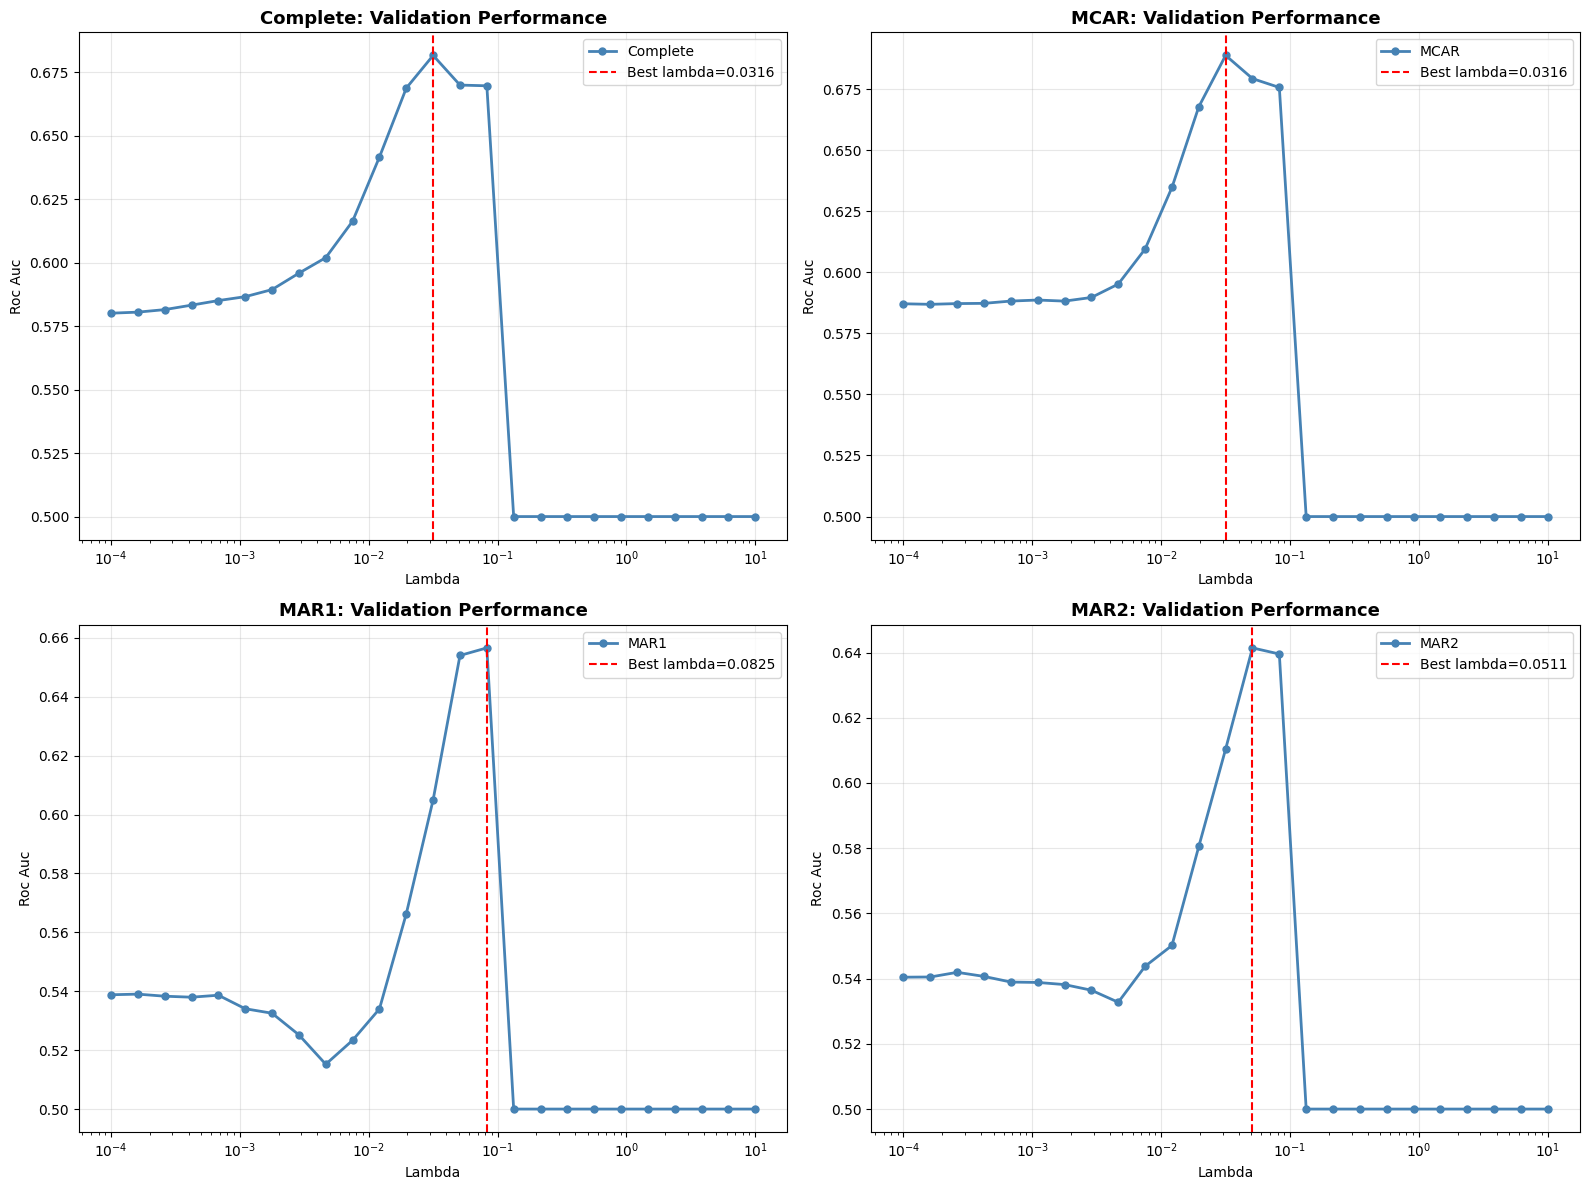

In [8]:
# Visualize results for different mechanisms on validation set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

mechanisms_to_plot = ['Complete', 'MCAR', 'MAR1', 'MAR2']

for idx, mechanism_name in enumerate(mechanisms_to_plot):
    if mechanism_name in fista_models:
        fista_model = fista_models[mechanism_name]
        fista_model.plot(measure=measure, ax=axes[idx], label=f'{mechanism_name}', color='steelblue')
        axes[idx].set_title(f'{mechanism_name}: Validation Performance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

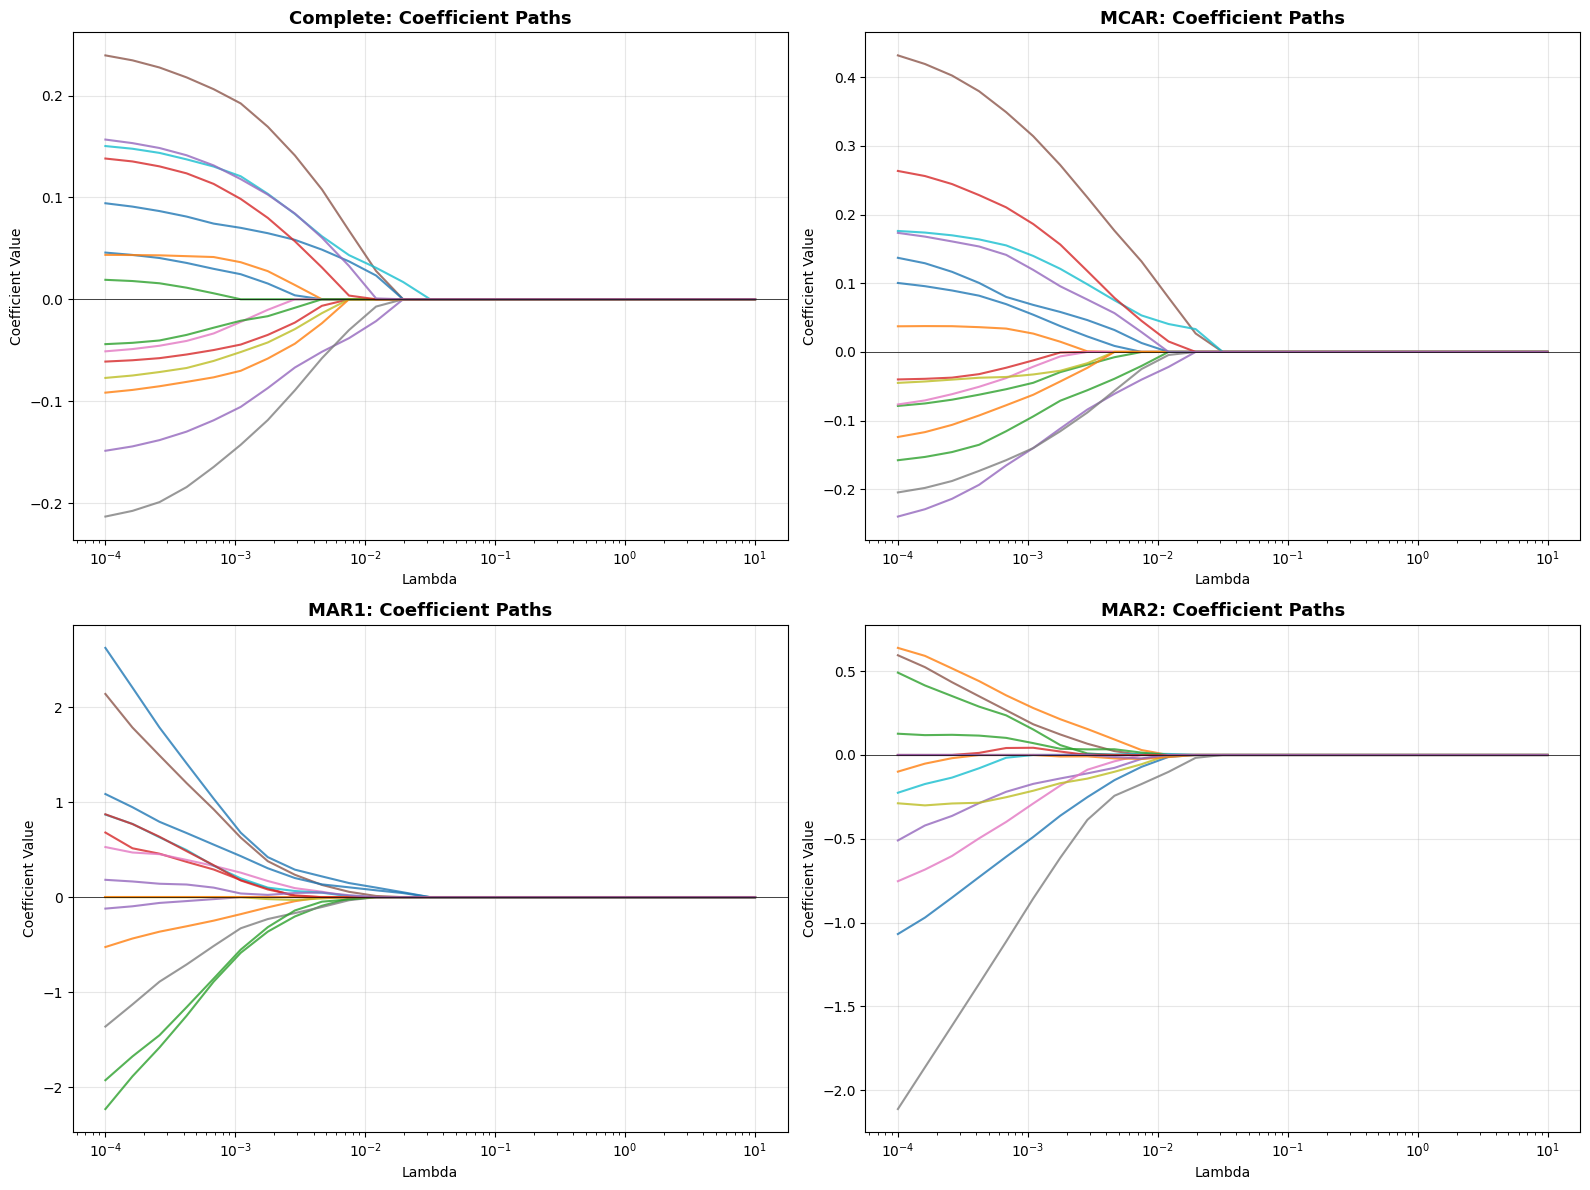

In [9]:
# Visualize coefficient paths for selected mechanisms on validation set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

mechanisms_to_plot = ['Complete', 'MCAR', 'MAR1', 'MAR2']

for idx, mechanism_name in enumerate(mechanisms_to_plot):
    if mechanism_name in fista_models:
        fista_model = fista_models[mechanism_name]
        fista_model.plot_coefficients(ax=axes[idx], top_n=15)
        axes[idx].set_title(f'{mechanism_name}: Coefficient Paths', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Comparison with scikit-learn Implementation

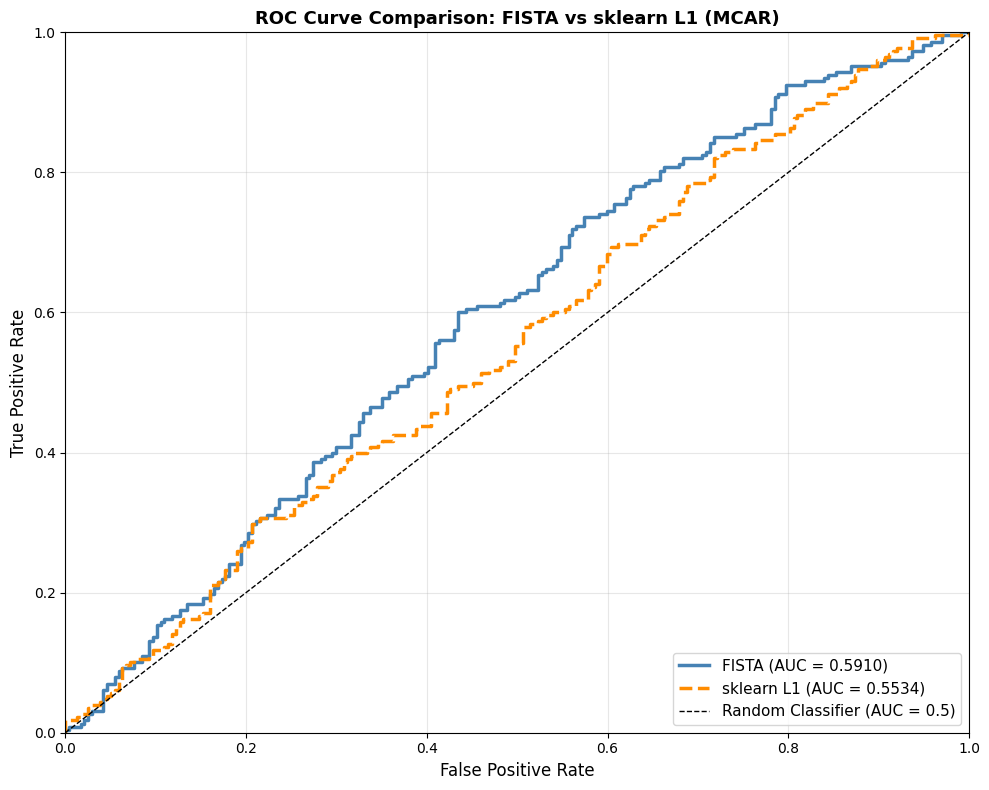

In [10]:
mechanism_to_compare = 'MCAR'
y_train_mcar, y_valid_mcar, y_test_mcar = missing_mechanisms[mechanism_to_compare]

# Get the corresponding FISTA model
fista_mcar = fista_models[mechanism_to_compare]

# Filter observed samples
train_mask = y_train_mcar != -1
valid_mask = y_valid_mcar != -1
test_mask = y_test_mcar != -1

X_train_obs = X_train_scaled[train_mask]
y_train_obs = y_train_mcar[train_mask]
X_test_obs = X_test_scaled[test_mask]
y_test_obs = y_test_mcar[test_mask]

# Train sklearn LogisticRegression with L1 penalty on observed data
sklearn_lr = LogisticRegression(penalty='l1', random_state=42, solver='saga')
sklearn_lr.fit(X_train_obs, y_train_obs)

# Get predictions from both models
fista_proba = fista_mcar.predict_proba(X_test_obs)[:, 1]
sklearn_proba = sklearn_lr.predict_proba(X_test_obs)[:, 1]

fista_fpr, fista_tpr, _ = roc_curve(y_test_obs, fista_proba)
sklearn_fpr, sklearn_tpr, _ = roc_curve(y_test_obs, sklearn_proba)

fista_auc = auc(fista_fpr, fista_tpr)
sklearn_auc = auc(sklearn_fpr, sklearn_tpr)

# Plot ROC curves comparison
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fista_fpr, fista_tpr, label=f'FISTA (AUC = {fista_auc:.4f})', 
        linewidth=2.5, color='steelblue')
ax.plot(sklearn_fpr, sklearn_tpr, label=f'sklearn L1 (AUC = {sklearn_auc:.4f})', 
        linewidth=2.5, color='darkorange', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve Comparison: FISTA vs sklearn L1 ({mechanism_to_compare})', 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()
